# When the combinatorial code appeared

Two figures from A. Pittis's `PILLARS_RECAP.md` (Pillar II), rebuilt here so they come
out of this repository's own code and binarisation.

| | question |
|---|---|
| **1 · The first three stages** | at one, two and three receptors, how many odorants are read by more than one of them? |
| **2 · The trajectory** | the same question across the whole tree, from `node_1` to the 433 human receptors |

The claim both support: **a combinatorial code appears at the very first duplication and
grows at every one after it, with no selection required.** One receptor cannot produce a
combinatorial code; two can, and immediately do.

## One difference from `06`, and it matters

`06.code_trajectory` runs with **no experimental overlay** — every cell, ancestral and
extant, is a prediction. That is deliberate there: overlaying measurements on the extant
tips only would put a data-source discontinuity on every ancestor-to-tip edge.

The memo's figures use the **overlay**: measured M2OR values are written over the extant
rows. That is why its endpoint is 687 odorants and `06`'s is 668. Both are in
`Tables/06_endpoint_overlay.csv`.

**This notebook uses the overlay**, so that it reproduces the published figures. Ancestral
rows are unaffected either way — a reconstructed sequence has no measurements. The
difference lives entirely in the extant endpoint, and the discontinuity `06` avoids is
real, so prefer `06`'s numbers for any ancestor-to-tip comparison.

In [7]:
import sys
sys.path.append("../../scripts")

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

from plotting_functions import custom_plots, FIGSIZE
from ancestral_sets import (ASR_MATRIX, REF_MATRIX, PAIRS, FASTA, CLASSES,
                            density_grid, mpl_times, raw_times, trajectory,
                            save_fig, save_table)
from calibration import density_fill, reference_calibration_map

plt.rcParams.update(custom_plots())

# The folder palette, identical to 01-06 so a class keeps one colour everywhere.
COMMON_COL, CLASS1_COL, CLASS2_COL = "#5F6A72", "#7f1734", "#557c99"

# Odorants both classes detect, and the "read by exactly one receptor" bar: the same
# light grey, because in both cases it is the neutral band the two classes sit either
# side of.
BOTH_COL = SINGLE_BAR = "#c9c9c4"
# Read by >=2 receptors. BOTH_COL's gold from 06, reused because it carries the same
# meaning here -- detected by more than one thing.
COMB_COL = "#b08a3e"
TOTAL_COL, SINGLE_LINE = "#3a3a38", COMMON_COL

_, _, fills, _ = density_grid()
ASR_CUT = fills["asr"].cut

classes = pd.read_csv(CLASSES)
leaf_class = dict(zip(classes.leaf_id, classes.OR_class))

print(f"ASR density cut {ASR_CUT:.4f}   (the calibrated cut for reconstructed nodes)")

ASR density cut 0.8875   (the calibrated cut for reconstructed nodes)


## 1 · The first three stages

Three snapshots of the earliest repertoire:

| stage | receptors | what it is |
|---|---|---|
| **S0** | `node_1` | the single gnathostome OR ancestor |
| **S1** | `node_2`, `node_3` | after the first duplication — the two class ancestors |
| **S2** | `node_4`, `node_5`, `node_6` | after the next two |

For each, count the odorants **detected** (bound by ≥ 1 receptor of the stage) and split
them into **labelled line** (exactly one receptor) and **combinatorial** (two or more).

Shown at two cuts. The raw `p ≥ 0.5` panel is the model default and over-calls badly — it
is here because the memo shows it, and because the *pattern* is the point: the fraction
rises the same way under either cut, so it is not an artefact of where the line is drawn.
`p ≥ 0.8875` is this folder's calibrated cut, and those are the numbers to quote.

> Stage 2 is reported as {`node_4`, `node_5`, `node_6`}. OR2AT4's placement sits on a very
> long branch next to the outgroup, which is long-branch-attraction geometry that
> bootstrapping cannot detect; the memo carries a 4-way version as a sensitivity.

In [8]:
STAGES = {"S0": ["node_1"],
          "S1": ["node_2", "node_3"],
          "S2": ["node_4", "node_5", "node_6"]}
STAGE_LABEL = {"S0": "1 receptor\n(node_1)",
               "S1": "2 receptors\n(node_2, node_3)",
               "S2": "3 receptors\n(node_4/5/6)"}

asr = pd.read_csv(ASR_MATRIX, index_col=0)
asr.index = [str(i).replace("_ASR", "") for i in asr.index]
lig = [c for c in asr.columns if c.startswith("SML")]

rows = []
for panel, cut in [("raw", 0.5), ("calibrated", ASR_CUT)]:
    for stage, nodes in STAGES.items():
        detectors = (asr.loc[nodes, lig].values > cut).sum(axis=0)
        encoded = int((detectors > 0).sum())
        single = int((detectors == 1).sum())
        comb = int((detectors >= 2).sum())
        rows.append({"panel": panel, "cut": round(cut, 4), "stage": stage,
                     "n_receptors": len(nodes), "encoded": encoded,
                     "labelled_line": single, "combinatorial": comb,
                     "pct_combinatorial": round(100 * comb / encoded, 1) if encoded else 0.0})

stages = pd.DataFrame(rows)
save_table(stages, "07_stages")
stages

,panel,cut,stage,n_receptors,encoded,labelled_line,combinatorial,pct_combinatorial
0,raw,0.5000,S0,1,177,177,0,0.0
1,raw,0.5000,S1,2,216,189,27,12.5
2,raw,0.5000,S2,3,265,133,132,49.8
3,calibrated,0.8875,S0,1,21,21,0,0.0
4,calibrated,0.8875,S1,2,27,25,2,7.4
5,calibrated,0.8875,S2,3,53,36,17,32.1


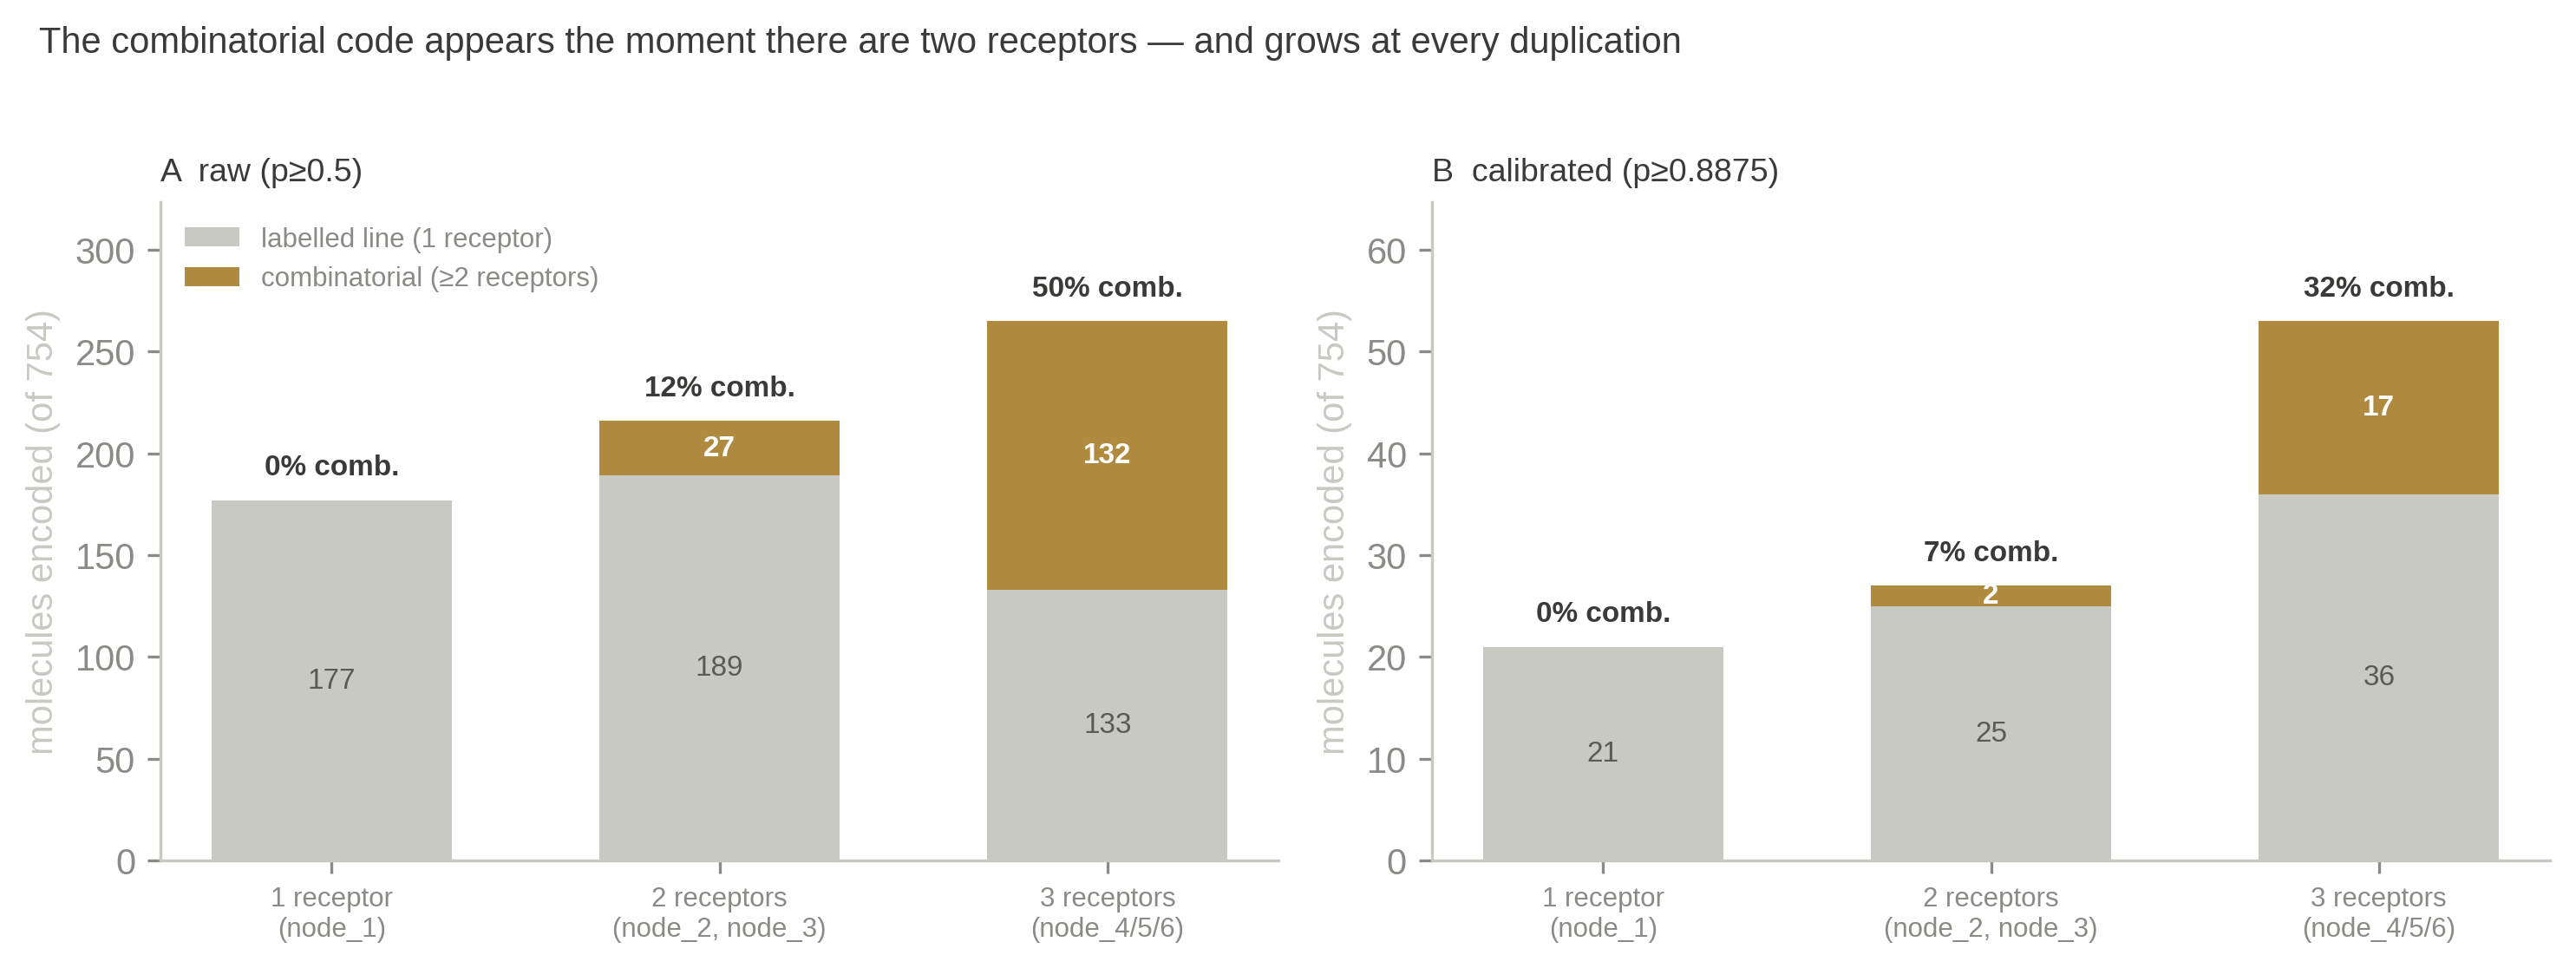

S0  1 receptor(s):  21 encoded,  21 by one,   0 by ≥2  (0.0% combinatorial)
S1  2 receptor(s):  27 encoded,  25 by one,   2 by ≥2  (7.4% combinatorial)
S2  3 receptor(s):  53 encoded,  36 by one,  17 by ≥2  (32.1% combinatorial)


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(FIGSIZE[0] * 2.5, FIGSIZE[1] * 1.2))
fig.suptitle("The combinatorial code appears the moment there are two receptors "
             "— and grows at every duplication",
             fontsize=10, color="#3a3a38", x=0.02, ha="left", y=1.02)

for ax, (panel, title) in zip(axes, [("raw", "A  raw (p≥0.5)"),
                                     ("calibrated", f"B  calibrated (p≥{ASR_CUT:.4f})")]):
    block = stages[stages.panel == panel].set_index("stage").loc[list(STAGES)]
    x = np.arange(len(block))

    ax.bar(x, block.labelled_line, width=0.62, color=SINGLE_BAR,
           label="labelled line (1 receptor)")
    ax.bar(x, block.combinatorial, bottom=block.labelled_line, width=0.62,
           color=COMB_COL, label="combinatorial (≥2 receptors)")

    for i, r in enumerate(block.itertuples()):
        if r.labelled_line:
            # dark text: the grey bar is too light to carry white
            ax.text(i, r.labelled_line / 2, f"{r.labelled_line}", ha="center", va="center",
                    fontsize=8, color="#5a5a57")
        if r.combinatorial:
            ax.text(i, r.labelled_line + r.combinatorial / 2, f"{r.combinatorial}",
                    ha="center", va="center", fontsize=8, color="white", fontweight="bold")
        ax.text(i, r.encoded + block.encoded.max() * 0.035,
                f"{r.pct_combinatorial:.0f}% comb." if r.pct_combinatorial else "0% comb.",
                ha="center", va="bottom", fontsize=8, fontweight="bold", color="#3a3a38")

    ax.set_xticks(x)
    ax.set_xticklabels([STAGE_LABEL[s] for s in block.index], fontsize=7.5)
    ax.set_ylabel("molecules encoded (of 754)")
    ax.set_ylim(0, block.encoded.max() * 1.22)
    ax.set_title(title, fontsize=9, loc="left", color="#3a3a38")

axes[0].legend(frameon=False, fontsize=7.5, loc="upper left")
plt.tight_layout()
save_fig(fig, "07_stages")
plt.show()

for r in stages[stages.panel == "calibrated"].itertuples():
    print(f"{r.stage}  {r.n_receptors} receptor(s): {r.encoded:>3} encoded, "
          f"{r.labelled_line:>3} by one, {r.combinatorial:>3} by ≥2  "
          f"({r.pct_combinatorial}% combinatorial)")

## 2 · The trajectory, `node_1` to the human repertoire

The same question across the whole tree. The x axis is **relative time** on the
mean-path-length ultrametric tree: the repertoire at time *t* is the set of lineages
crossing *t*, which needs no ordering choice and no arbitrary path through the tree.

Three views:

- **odorants by detecting class** — how the Class I / shared / Class II partition fills in
- **single detector vs combinatorial** — the labelled-line count *falls* while the
  combinatorial count climbs
- **receptors per class** — drawn on both axes, because they disagree about *timing*

### Why the third panel has two line styles

Ultrametricising assumes rate variation averages out. That assumption is under most strain
exactly here, where the rate difference is systematic and clade-level. So both axes are
drawn: solid is the ultrametric (clock-corrected) axis, dotted is raw substitutions (no
clock at all). They bracket the truth rather than one being right.

They disagree on timing — Class I's share of the repertoire at twenty receptors is 0.10 on
relative time and 0.65 on raw substitutions — but **agree on the shape**: Class I saturates
near 62 while Class II keeps expanding. *Treat the shape as the result and the timing as
approximate.*

In [10]:
# The overlaid call matrix: ancestral rows filled from predictions alone, extant rows
# filled the same way and then overwritten wherever M2OR has a measurement.
asr_p = pd.read_csv(ASR_MATRIX, index_col=0)
asr_p.index = [str(i).replace("_ASR", "") for i in asr_p.index]
ref_p = pd.read_csv(REF_MATRIX, index_col=0)
ref_p = ref_p[[str(i).startswith("9606") for i in ref_p.index]]
cols = [c for c in asr_p.columns if c.startswith("SML") and c in ref_p.columns]
asr_p, ref_p = asr_p[cols], ref_p[cols]

# Sequences, so the experimental layer joins on exact amino-acid identity rather than on
# accession -- M2OR mutants share their parent's accession and must not fold onto it.
seqs, pid, buf = {}, None, []
for line in open(FASTA):
    line = line.rstrip()
    if line.startswith(">"):
        if pid:
            seqs[pid] = "".join(buf).upper()
        pid, buf = line[1:].split()[0], []
    else:
        buf.append(line)
if pid:
    seqs[pid] = "".join(buf).upper()

seq_to_pid = {}
for p in ref_p.index:
    seq_to_pid.setdefault(seqs[p], p)

pairs = pd.read_csv(PAIRS, usecols=["Species", "Sequence", "Responsive", "smiles_id"])
human = pairs[pairs.Species.str.lower().str.contains("homo")].copy()
human["Sequence"] = human.Sequence.str.upper().str.strip()
human["pid"] = human.Sequence.map(seq_to_pid)
measured = (human[human.pid.notna() & human.smiles_id.isin(cols)]
            .groupby(["pid", "smiles_id"]).Responsive.max())

row_of = {p: i for i, p in enumerate(ref_p.index)}
col_of = {c: j for j, c in enumerate(cols)}
tested = np.zeros(ref_p.shape, bool)
observed = np.zeros(ref_p.shape, float)
for (p, s), v in measured.items():
    tested[row_of[p], col_of[s]] = True
    observed[row_of[p], col_of[s]] = v

iso = reference_calibration_map(REF_MATRIX, PAIRS, FASTA)
asr_fill = density_fill(asr_p.values, iso, tested_mask=None)
ref_fill = density_fill(ref_p.values, iso, tested_mask=tested, experimental=observed)

overlaid = pd.concat([
    pd.DataFrame(asr_fill.matrix.astype(bool), index=asr_p.index, columns=cols),
    pd.DataFrame(ref_fill.matrix.astype(bool), index=ref_p.index, columns=cols),
])
overlaid = overlaid[~overlaid.index.duplicated()]

print(f"{len(measured)} measured cells, {int(measured.sum())} positive")
print(f"ASR fill     cut {asr_fill.cut:.4f}  density {asr_fill.density:.4%}  (no overlay possible)")
print(f"extant fill  cut {ref_fill.cut:.4f}  density {ref_fill.density:.4%}  (measurements written over)")
print(f"grid         {overlaid.shape[0]} rows x {overlaid.shape[1]} ligands")

23782 measured cells, 1128 positive
ASR fill     cut 0.8875  density 2.2623%  (no overlay possible)
extant fill  cut 0.8917  density 2.7453%  (measurements written over)
grid         865 rows x 754 ligands


In [11]:
mpl = mpl_times()
raw = raw_times()

traj = trajectory(mpl, binary=overlaid)
traj_raw = trajectory(raw, binary=overlaid)
save_table(traj, "07_trajectory")

CHECKPOINTS = [0.0, 0.75, 0.83, 0.90, 0.96, 1.0]
check = trajectory(mpl, grid=np.array(CHECKPOINTS), binary=overlaid)


def receptors(row):
    # Class I + Class II, or the lineage count while the split is undefined:
    # node_1 belongs to neither clade, so at t = 0 there is one unassigned lineage.
    if row.n_class_I or row.n_class_II:
        return f"{int(row.n_class_I)} + {int(row.n_class_II)}"
    return str(int(row.n_lineages))


table = pd.DataFrame({
    "relative time": [f"{t:g}" for t in check.t],
    "receptors (Class I + Class II)": [receptors(r) for r in check.itertuples()],
    "odorants detected": check.n_detected.astype(int).values,
    "single detector": check.n_single.astype(int).values,
    "combinatorial (>=2)": check.n_combinatorial.astype(int).values,
    "Class I only / both / Class II only": [
        "–" if not (r.only_I or r.both or r.only_II)
        else f"{int(r.only_I)} / {int(r.both)} / {int(r.only_II)}"
        for r in check.itertuples()],
}).set_index("relative time").T
save_table(table.reset_index(), "07_checkpoints", index=False)
table

relative time,0,0.75,0.83,0.9,0.96,1
receptors (Class I + Class II),1,26 + 112,37 + 184,54 + 250,56 + 310,62 + 371
odorants detected,21,549,650,660,666,687
single detector,21,109,101,93,95,61
combinatorial (>=2),0,440,549,567,571,626
Class I only / both / Class II only,–,28 / 233 / 288,38 / 283 / 329,37 / 340 / 283,33 / 344 / 289,17 / 370 / 300


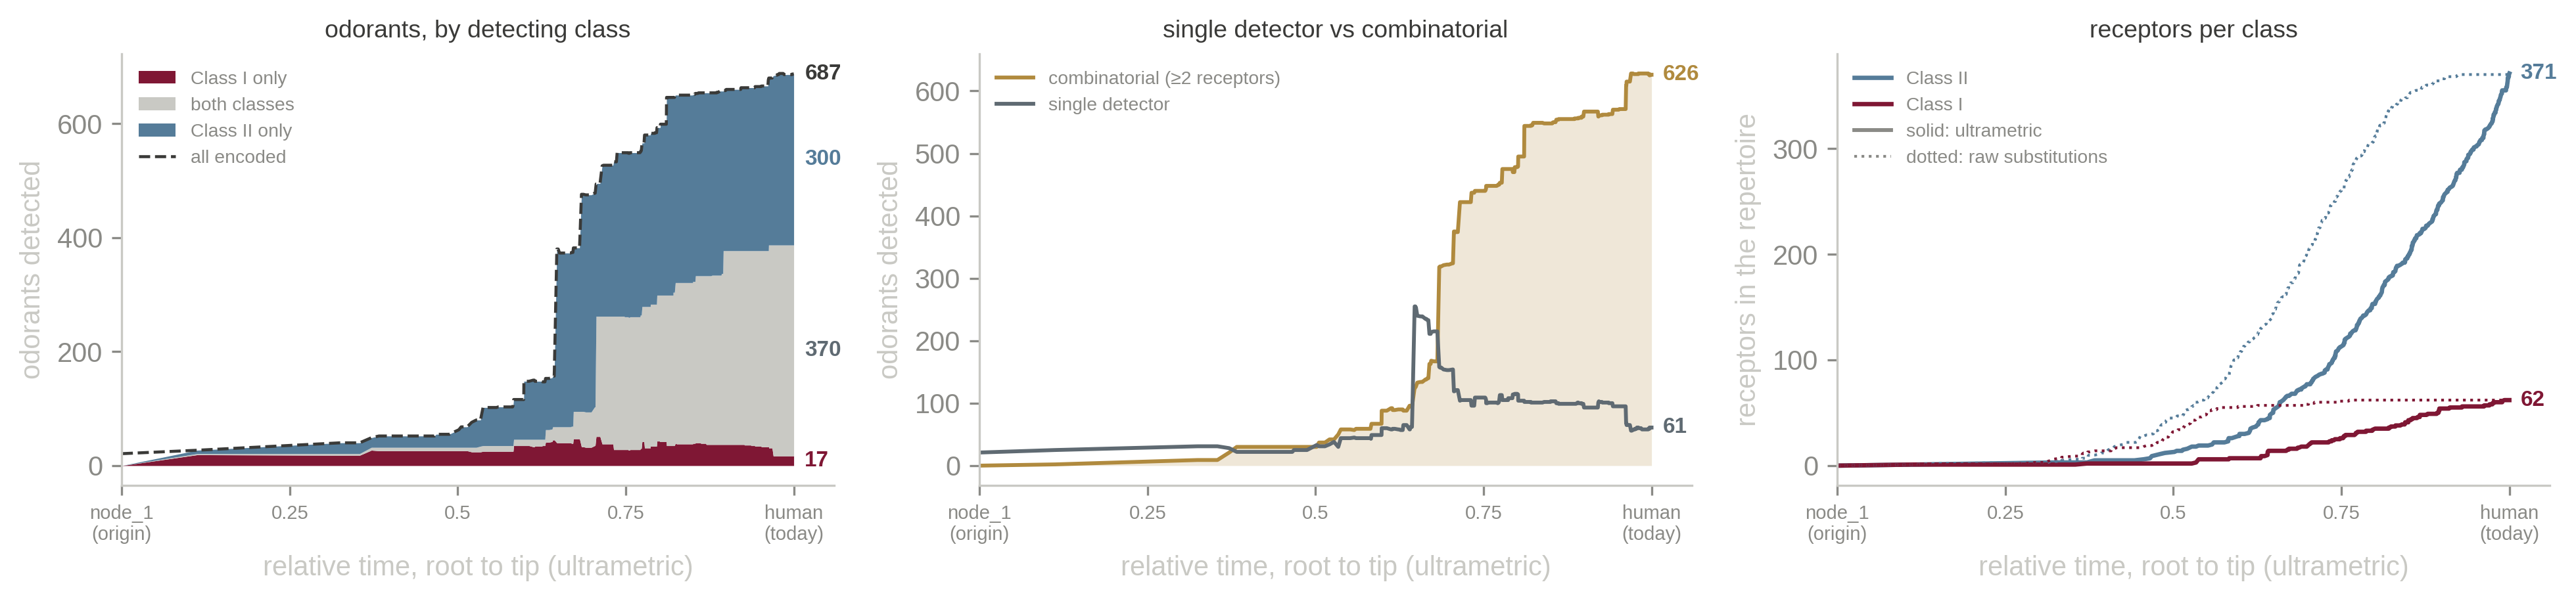

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(FIGSIZE[0] * 3.3, FIGSIZE[1] * 1.05))


def endlabel(ax, y, text, colour, dy=0.0):
    ax.annotate(text, xy=(1.0, y), xytext=(4, dy), textcoords="offset points",
                fontsize=8, fontweight="bold", color=colour, va="center")


# --- odorants, by detecting class -------------------------------------------
ax = axes[0]
t = traj.t.values
base = np.zeros(len(traj))
for col, colour, name in [("only_I", CLASS1_COL, "Class I only"),
                          ("both", BOTH_COL, "both classes"),
                          ("only_II", CLASS2_COL, "Class II only")]:
    ax.fill_between(t, base, base + traj[col].values, color=colour, lw=0, label=name)
    base = base + traj[col].values
ax.plot(t, traj.n_detected, color=TOTAL_COL, lw=1.1, ls="--", label="all encoded")
last = traj.iloc[-1]
endlabel(ax, last.n_detected, f"{int(last.n_detected)}", TOTAL_COL)
endlabel(ax, last.only_I / 2, f"{int(last.only_I)}", CLASS1_COL)
endlabel(ax, last.only_I + last.both / 2, f"{int(last.both)}", COMMON_COL)  # grey band, darker text
endlabel(ax, last.only_I + last.both + last.only_II / 2, f"{int(last.only_II)}", CLASS2_COL)
ax.set_ylabel("odorants detected")
ax.set_title("odorants, by detecting class", fontsize=9, color="#3a3a38")
ax.legend(frameon=False, fontsize=6.8, loc="upper left")

# --- single vs combinatorial -------------------------------------------------
ax = axes[1]
ax.fill_between(t, 0, traj.n_combinatorial, color=COMB_COL, alpha=0.20, lw=0)
ax.plot(t, traj.n_combinatorial, color=COMB_COL, lw=1.4, label="combinatorial (≥2 receptors)")
ax.plot(t, traj.n_single, color=SINGLE_LINE, lw=1.4, label="single detector")
endlabel(ax, last.n_combinatorial, f"{int(last.n_combinatorial)}", COMB_COL)
endlabel(ax, last.n_single, f"{int(last.n_single)}", SINGLE_LINE)
ax.set_ylabel("odorants detected")
ax.set_title("single detector vs combinatorial", fontsize=9, color="#3a3a38")
ax.legend(frameon=False, fontsize=6.8, loc="upper left")

# --- receptors per class, on both axes ---------------------------------------

ax = axes[2]
for frame, style, width in [(traj, "-", 1.6), (traj_raw, ":", 1.0)]:
    ax.plot(frame.t, frame.n_class_II, color=CLASS2_COL, ls=style, lw=width)
    ax.plot(frame.t, frame.n_class_I, color=CLASS1_COL, ls=style, lw=width)
endlabel(ax, last.n_class_II, f"{int(last.n_class_II)}", CLASS2_COL)
endlabel(ax, last.n_class_I, f"{int(last.n_class_I)}", CLASS1_COL)
ax.set_ylabel("receptors in the repertoire")
ax.set_title("receptors per class", fontsize=9, color="#3a3a38")
ax.legend(handles=[Line2D([], [], color=CLASS2_COL, lw=1.6, label="Class II"),
                   Line2D([], [], color=CLASS1_COL, lw=1.6, label="Class I"),
                   Line2D([], [], color="#8a8a86", lw=1.4, ls="-", label="solid: ultrametric"),
                   Line2D([], [], color="#8a8a86", lw=1.0, ls=":", label="dotted: raw substitutions")],
          frameon=False, fontsize=6.8, loc="upper left")

for ax in axes:
    ax.set_xlim(0, 1.06)
    ax.set_xticks([0, 0.25, 0.5, 0.75, 1.0])
    ax.set_xticklabels(["node_1\n(origin)", "0.25", "0.5", "0.75", "human\n(today)"], fontsize=7)
    ax.set_xlabel("relative time, root to tip (ultrametric)")

plt.tight_layout()
save_fig(fig, "07_code_growth")
plt.show()

## What reproduces, and what does not

Everything above comes from this repository's code. Against the memo's published table:

- **The endpoint matches exactly** — 62 + 371 receptors, 687 odorants detected, 61 single
  detector, 626 combinatorial, and the 17 / 370 / 300 partition. That last agreement is
  the meaningful one: it closes on Pillar I's partition of the extant matrix, computed a
  completely different way.
- **The stage figure matches exactly** at both cuts — 177/0, 189+27, 133+132 raw, and
  21/0, 25+2, 36+17 calibrated.
- **The intermediate checkpoints match on every odorant column at t = 0, 0.75, 0.83 and
  0.90**, and drift by a few receptors. The `t = 0.96` column differs more (666 vs 678
  detected). That region is tie-dense — 21 node times fall within 0.01 of it — so the
  counts move sharply with the exact sample point; evaluating at 0.965 instead gives
  57 + 318 and 680 detected, essentially the memo's column. It is a rounding difference in
  where the column was sampled, not a disagreement about method.

## What these two figures do and do not support

**They support:** a combinatorial code requires no selective explanation. One receptor
cannot make one; two can, and 7.4% of what they detect is already read by both. By three
receptors it is 32%. Duplication of a broadly-tuned ancestor produces this for free.

**They do not support** — and the memo is explicit about each:

- that no selection occurred. Absence of a *need* for selection is not absence of selection.
- that the code *grew more* combinatorial over evolution in any interesting sense. Beyond
  ~50 receptors the observed fraction is *below* what independent rows of the same breadths
  would force. The rise is arithmetic.
- that labelled lines are a transient the growing repertoire eliminates. The fall in single
  detectors is produced by a handful of hyper-broad rows; blanking rows above 100 odorants
  turns 219 → 61 into 168 → 154.
- that "labelled line at S2" is a property of the molecule. 97% of those odorants are
  combinatorially encoded in the extant code.
- anything about **when** the classes reached their relative sizes. The two axes in panel 3
  bracket it and a human-only tree cannot narrow it.

Set sizes here are small — S1 detects 27 odorants and S2 detects 53 — so no chemistry or
odour-descriptor claim about these stages survives multiple-testing correction. `06`'s
composition null is the companion check: it reproduces the class-overlap shape by
resampling extant receptors, with no tree involved.